# Naive Bayes Classifier

In [4]:
# Imports
%pip install pandas numpy matplotlib scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score, brier_score_loss
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV


## 1. Data Preparation

### 1-1. Data Loading

In [ ]:
# Import `all_dataset.csv`
df = pd.read_csv('datasets/all_dataset.csv')

df.head()

,timestamp,BLUE.HEXTECH_DRAGON.kills,BLUE.WATER_DRAGON.kills,BLUE.FIRE_DRAGON.kills,BLUE.EARTH_DRAGON.kills,BLUE.AIR_DRAGON.kills,BLUE.CHEMTECH_DRAGON.kills,BLUE.ELDER_DRAGON.kills,BLUE.RIFTHERALD.kills,BLUE.BARON_NASHOR.kills,...,soul_Mountain,soul_Ocean,BLUE.minionRatio,RED.minionRatio,BLUE.totalGoldRatio,RED.totalGoldRatio,BLUE.levelRatio,RED.levelRatio,BLUE.kda,RED.kda
0,0,0,0,0,0,0,0,0,0,0,...,0,0,NaN,NaN,inf,inf,inf,inf,NaN,NaN
1,60017,0,0,0,0,0,0,0,0,0,...,0,0,0.000000,0.000000,0.041655,0.041655,0.000083,0.000083,NaN,NaN
2,120046,0,0,0,0,0,0,0,0,0,...,0,0,0.000067,0.000092,0.024016,0.027648,0.000050,0.000050,0.000000,inf
3,180116,0,0,0,0,0,0,0,0,0,...,0,0,0.000333,0.000272,0.024978,0.026333,0.000072,0.000072,0.000000,inf
4,240131,0,0,0,0,0,0,0,0,0,...,0,0,0.000362,0.000346,0.026027,0.028230,0.000067,0.000075,0.666667,6.0


### 1-2. Remove irrelevant columns

In [8]:
# Drop `timestamp` column
df = df.drop(['timestamp'], axis=1)

### 1-3. Handle Missing Values

In [9]:
# Replace missing values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)
# Replace NaN with 0
df.fillna(0, inplace=True)

# Check for missing values
missing_values = df.isnull().sum()
missing_values

,0
BLUE.HEXTECH_DRAGON.kills,0
BLUE.WATER_DRAGON.kills,0
BLUE.FIRE_DRAGON.kills,0
BLUE.EARTH_DRAGON.kills,0
BLUE.AIR_DRAGON.kills,0
BLUE.CHEMTECH_DRAGON.kills,0
BLUE.ELDER_DRAGON.kills,0
BLUE.RIFTHERALD.kills,0
BLUE.BARON_NASHOR.kills,0
BLUE.HORDE.kills,0


### 1-4. Define Target and Features

In [10]:
X = df.drop(['winner'], axis=1)
y = df['winner']

### 1-5. Univariate Feature Selection

In [11]:
# Apply SelectKBest with different scoring functions for numerical features with numerical target
selector_f = SelectKBest(f_classif)
X_new_f = selector_f.fit_transform(X, y)

# Get selected feature names and their scores
selected_features_f = X.columns[selector_f.get_support()]
scores_f = selector_f.scores_

# Display results
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector_f.scores_
})
feature_scores = feature_scores.sort_values('Score', ascending=False)
print(feature_scores)

                          Feature          Score
39                        RED.kda  675705.177979
38                       BLUE.kda  634968.642143
22      BLUE.TOWER_BUILDING.kills  289962.609529
21              RED.ATAKHAN.kills  223154.153936
23       RED.TOWER_BUILDING.kills  220259.086623
18           RED.RIFTHERALD.kills  169520.552677
10             BLUE.ATAKHAN.kills  169390.275893
24  BLUE.INHIBITOR_BUILDING.kills  148068.701069
35             RED.totalGoldRatio  144470.520709
20                RED.HORDE.kills  140229.752953
34            BLUE.totalGoldRatio  130597.738661
25   RED.INHIBITOR_BUILDING.kills  129324.680701
7           BLUE.RIFTHERALD.kills  101253.458279
9                BLUE.HORDE.kills   87575.661962
19         RED.BARON_NASHOR.kills   87109.134593
12         RED.WATER_DRAGON.kills   86973.789300
1         BLUE.WATER_DRAGON.kills   77113.522870
11       RED.HEXTECH_DRAGON.kills   74419.859573
0       BLUE.HEXTECH_DRAGON.kills   68258.209027
4           BLUE.AIR

In [12]:
# Select features with a score higher than 10000
best_features = feature_scores[feature_scores['Score'] > 10000]['Feature']

# Create a new dataframe with only the best features
X_best = X[best_features]

# Display the best features
print(best_features)

39                          RED.kda
38                         BLUE.kda
22        BLUE.TOWER_BUILDING.kills
21                RED.ATAKHAN.kills
23         RED.TOWER_BUILDING.kills
18             RED.RIFTHERALD.kills
10               BLUE.ATAKHAN.kills
24    BLUE.INHIBITOR_BUILDING.kills
35               RED.totalGoldRatio
20                  RED.HORDE.kills
34              BLUE.totalGoldRatio
25     RED.INHIBITOR_BUILDING.kills
7             BLUE.RIFTHERALD.kills
9                  BLUE.HORDE.kills
19           RED.BARON_NASHOR.kills
12           RED.WATER_DRAGON.kills
1           BLUE.WATER_DRAGON.kills
11         RED.HEXTECH_DRAGON.kills
0         BLUE.HEXTECH_DRAGON.kills
4             BLUE.AIR_DRAGON.kills
15             RED.AIR_DRAGON.kills
13            RED.FIRE_DRAGON.kills
2            BLUE.FIRE_DRAGON.kills
3           BLUE.EARTH_DRAGON.kills
8           BLUE.BARON_NASHOR.kills
14           RED.EARTH_DRAGON.kills
16        RED.CHEMTECH_DRAGON.kills
36                  BLUE.lev

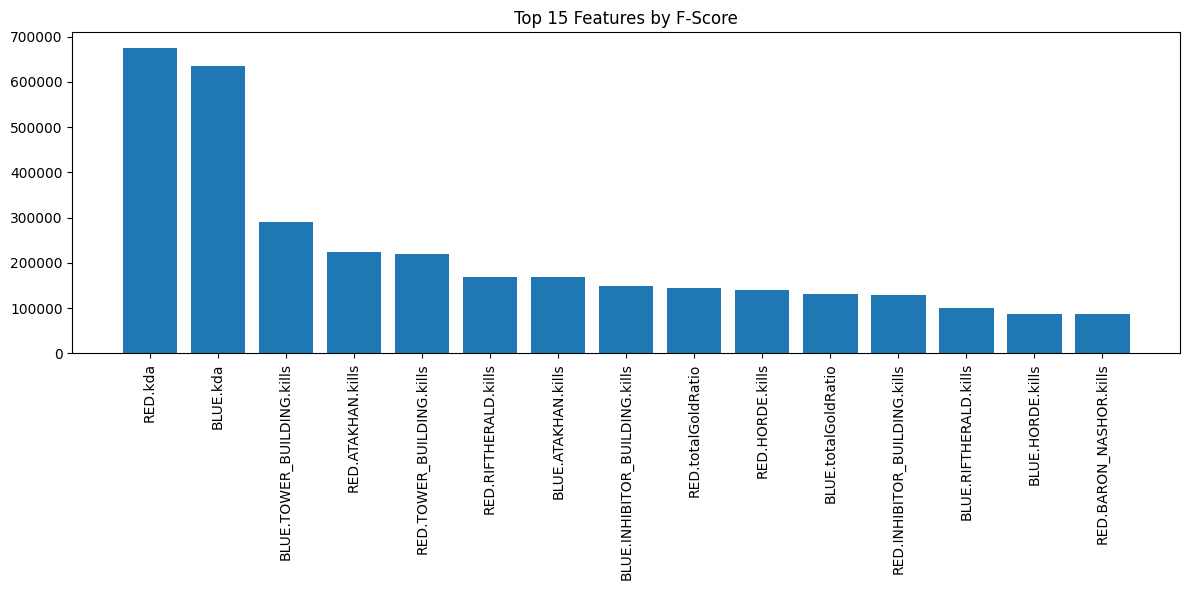

In [13]:
# Visualize feature importance
plt.figure(figsize=(12, 6))
plt.bar(feature_scores['Feature'][:15], feature_scores['Score'][:15])
plt.xticks(rotation=90)
plt.title('Top 15 Features by F-Score')
plt.tight_layout()
plt.show()

### 1-6. Train-Test Split

In [14]:
# Split the dataset into training and testing sets with best features only
X_train, X_test, y_train, y_test = train_test_split(X_best, y, test_size=0.2, random_state=42)

# Print train and test shapes
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5269809, 32) (1317453, 32) (5269809,) (1317453,)


## 2. Gaussian Naive Bayes Algorithm

In [15]:
# Initialize the classifier
model = GaussianNB()

# Train the model
model.fit(X_train, y_train)

GaussianNB()

## 3. Model Evaluation

### 3-1. Global Metrics

In [16]:
# Predict the test set
y_pred = model.predict(X_test)

********** MODEL SCORES **********
Mean Absolute Error (MAE): 0.3042
Mean Squared Error (MSE): 0.3042
Root Mean Squared Error (RMSE): 0.5516
R^2 Score: -0.2174
f1 Score: 0.6605
Precision Score: 0.7294
Recall Score: 0.6035
Brier Score: 0.3042
Accuracy: 0.6958
**********************************


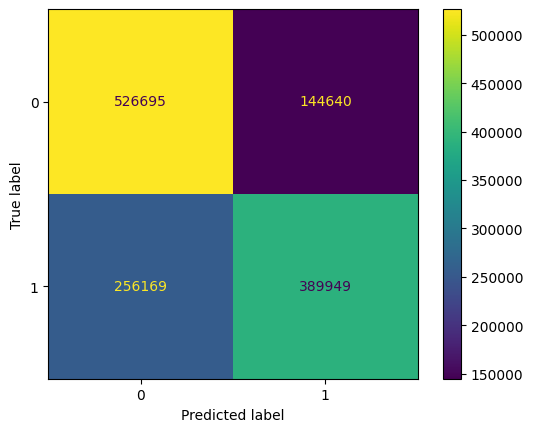

In [17]:
# Evaluate the model
def model_evaluation(y_test, y_pred):
    """
    Evaluate the model using :
    - Mean Absolute Error
    - Mean Squared Error
    - Root Mean Squared Error
    - R^2 Score
    - F1 Score
    - Precision Score
    - Recall Score
    """
    # Evaluate the model using MAE, MSE, RMSE, R^2 Score, F1 score, Precision Score and Recall Score
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    brier_score = brier_score_loss(y_test, y_pred)

    # Legacy mode (convert probabilities to binary; threshold set to '> 0.5')
    y_pred_binary = (y_pred > 0.5).astype(int)
    f1 = f1_score(y_test, y_pred_binary)
    precision = precision_score(y_test, y_pred_binary)
    recall = recall_score(y_test, y_pred_binary)
    accuracy = accuracy_score(y_test, y_pred_binary)

    # Print the scores
    print("********** MODEL SCORES **********")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R^2 Score: {r2:.4f}")
    print(f"f1 Score: {f1:.4f}")
    print(f"Precision Score: {precision:.4f}")
    print(f"Recall Score: {recall:.4f}")
    print(f"Brier Score: {brier_score:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print("**********************************")

    # Calculate the confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Display the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot()


model_evaluation(y_test, y_pred)

### 3-2. ROC Curve and AUC-ROc Score

ROC AUC: 0.6940373395331723


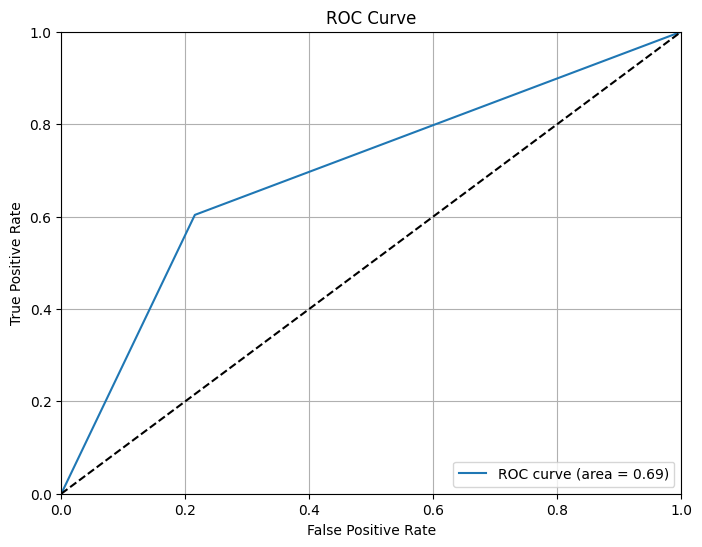

In [18]:
# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# Calculate the ROC AUC
roc_auc = roc_auc_score(y_test, y_pred)
print('ROC AUC:', roc_auc)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.grid()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

## 4. Fine Tuning

In [19]:
# Define hyperparameter distribution
param_dist = {
    'var_smoothing': loguniform(1e-9, 1e-3)  # Log-uniform distribution for better coverage
}

# Use RandomizedSearchCV
random_search = RandomizedSearchCV(
    model, param_distributions=param_dist, n_iter=50, scoring='accuracy', cv=5, random_state=42, n_jobs=-1
)

# Fit the model
random_search.fit(X_train, y_train)

# Best hyperparameters
print("Best parameters:", random_search.best_params_)

# Evaluate the best model
best_model = random_search.best_estimator_
accuracy = best_model.score(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

Best parameters: {'var_smoothing': 1.3289448722869192e-09}
Test Accuracy: 0.6957


Global metrcis doesn't change much after fine tuning. So, we will use the model without fine tuning to gain time.